In [1]:
from array import array
from typing import Optional, Callable
from dataclasses import dataclass
from graphviz import Digraph, Graph
from IPython.display import display
from random import choices, randint, choice

Ordinal = list[tuple[int, int]]

def canonical_ordinal(o: Ordinal) -> Ordinal:
    return [(min(j), max(j)) for j in o]

def naive_digraph_of_ordinal(enc: Ordinal) -> Digraph:
    rels = [str(i+1) for i in range(len(enc) + 1)]
    joins = enc.copy()
    g = Digraph()
    
    for r in rels:
        g.node(str(r), color='lightblue2', style="filled")

    while len(joins) > 0:
        l, r = joins.pop(0)

        new_rel = f'({rels[l-1]},{rels[r-1]})'
        g.node(new_rel, label="")
        g.edge(new_rel, rels[l-1])
        g.edge(new_rel, rels[r-1])
        rels[l-1] = new_rel
        
        rels.pop(r-1)
    
    return g, rels[0]

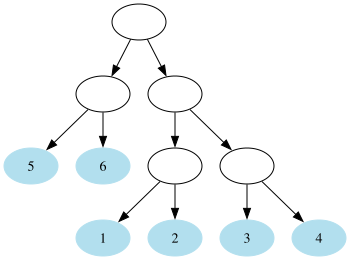

In [2]:
naive_digraph_of_ordinal(canonical_ordinal([(1,2), (2,3), (3,4), (1,2), (1,2)]))[0]

In [3]:
def cmp(d: Callable[[Ordinal, Ordinal], float], l: Ordinal, r: Ordinal):
    l = canonical_ordinal(l)
    r = canonical_ordinal(r)
    dist = d(l, r)
    print(f"{dist=}")
    
    display(naive_digraph_of_ordinal(l)[0])
    display(naive_digraph_of_ordinal(r)[0])

In [4]:
def normalised_hamming_distance(l: Ordinal, r: Ordinal) -> float:
    return sum(1 if lj != rj else 0 for lj, rj in zip(l, r)) / len(l)

dist=0.4


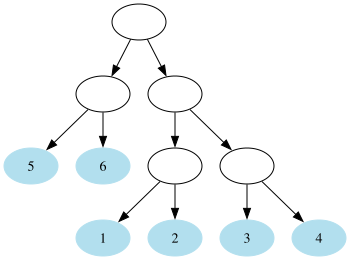

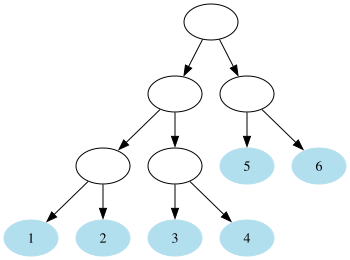

In [5]:
cmp(
    normalised_hamming_distance, 
    [(1,2), (2,3), (3,4), (1,2), (1,2)],
    [(1,2), (2,3), (1,2), (2,3), (1,2)],
)

In [6]:
def random_ordinal(n: int) -> Ordinal:
    def nrc(m: int, k: int) -> set[int]:
        population = list(range(1, m+1))
        res = set()
        while len(res) < k:
            res.add(choice(population))

        return res
    return [tuple(nrc(n - i, 2)) for i in range(n-1)]

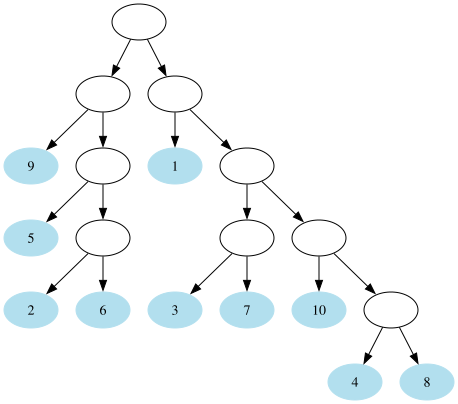

In [7]:
naive_digraph_of_ordinal(canonical_ordinal(random_ordinal(10)))[0]

In [8]:
def count_rnd_ordinals(n: int, steps: int) -> int:
    s = set()
    for _ in range(steps):
        s.add(naive_digraph_of_ordinal(canonical_ordinal(random_ordinal(n)))[1])
    return len(s)

In [9]:
[count_rnd_ordinals(n, 10_0 * n) for n in range(2, 7)]

[1, 3, 15, 100, 394]

[https://oeis.org/A001147](https://oeis.org/A001147)

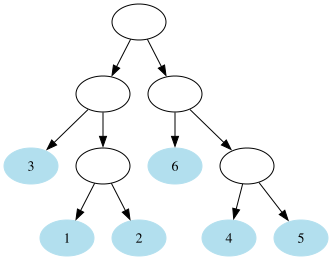

In [10]:
naive_digraph_of_ordinal(canonical_ordinal([(1,2), (3,4), (1,2), (2,3), (1,2)]))[0]

In [11]:
def naive_signature_of_ordinal(o: Ordinal) -> dict[int, int]:
    from collections import Counter
    
    offsets = [1] * (len(o) + 1)
    for _, i in o:
        j = sum(offsets[:i])
        offsets[j-1] += 1

    print(f"{offsets=}")
    return dict(Counter(offsets))

In [12]:
naive_signature_of_ordinal(canonical_ordinal([(1,2), (3,4), (1,2), (2,3), (1,2)]))

offsets=[1, 2, 3, 1, 3, 1]


{1: 3, 2: 1, 3: 2}

In [13]:
def tanimotto_sim(s1: dict[int, int], s2: dict[int, int]) -> float:
    keys = set().union(s1.keys()).union(s2.keys())
    intersection = sum(min(s1.get(k, 0), s2.get(k, 0)) for k in keys)
    sm = sum(max(s1.get(k, 0), s2.get(k, 0)) for k in keys)

    return intersection / sm

In [14]:
tanimotto_sim(
    naive_signature_of_ordinal(canonical_ordinal([(1,2), (3,4), (1,2), (2,3), (1,2)])),
    naive_signature_of_ordinal(canonical_ordinal([(1,2), (2,3), (3,4), (1,2), (1,2)]))
)

offsets=[1, 2, 3, 1, 3, 1]
offsets=[1, 2, 3, 2, 1, 2]


0.5

In [15]:
def tanimotto_signature_dist(l: Ordinal, r: Ordinal) -> float:
    return 1 - tanimotto_sim(
            naive_signature_of_ordinal(canonical_ordinal(l)),
            naive_signature_of_ordinal(canonical_ordinal(r))
        )

offsets=[1, 2, 3, 2, 1, 2]
offsets=[1, 2, 3, 2, 2, 1]
dist=0.0


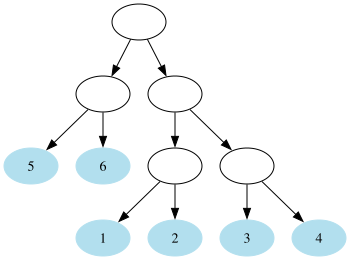

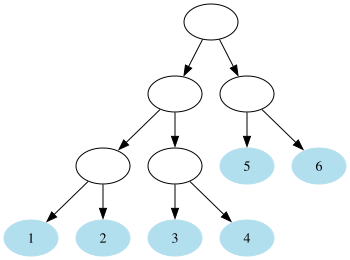

In [16]:
cmp(
    tanimotto_signature_dist,
    [(1,2), (2,3), (3,4), (1,2), (1,2)],
    [(1,2), (2,3), (1,2), (2,3), (1,2)],
)

offsets=[1, 2, 3, 2, 1, 2]
offsets=[1, 2, 3, 1, 2, 2]
dist=0.0


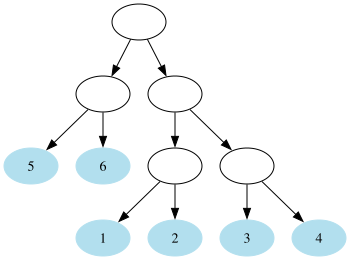

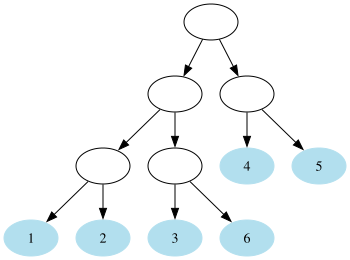

In [17]:
"""
Są różne, ale mają tę samą topologię, więc może warto nadal użyć tego do podziału na 2 chromosomy: topologia + przypisanie liści?
!!!NIE!!!
"""
cmp(
    tanimotto_signature_dist,
    [(1,2), (2,3), (3,4), (1,2), (1,2)],
    [(1,2), (2,5), (1,2), (2,3), (1,2)],
)

offsets=[1, 2, 5, 1, 1, 1]
offsets=[1, 2, 2, 2, 2, 2]
dist=0.8


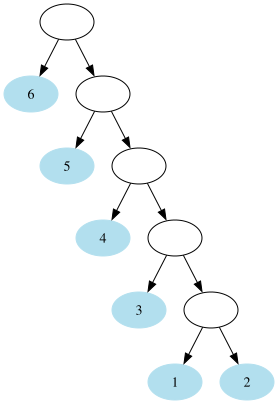

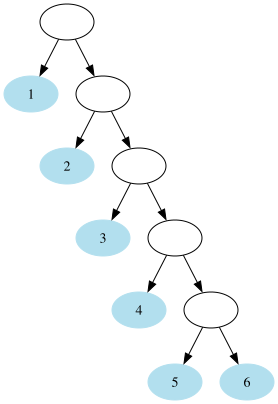

In [18]:
"""
Jednak nie, bo mają dokładnie tę samą topologię, a inne sygnatury
"""
cmp(
    tanimotto_signature_dist,
    [(1,2)] * 5,
    [(6 - i - 1, 6 - i) for i in range(0, 5)]
)

In [19]:
from typing import TypedDict
    
Tree = "int | TreeNode"
class TreeNode(TypedDict):
    left: Tree
    right: Tree
    val: int

def naive_tree_of_ordinal(enc: Ordinal) -> Tree:
    rels = [i+1 for i in range(len(enc) + 1)]
    joins = enc.copy()

    while len(joins) > 0:
        l, r = joins.pop(0)
        rels[l-1] = TreeNode(left=rels[l-1], right=rels[r-1], val=0)
        rels.pop(r-1)

    return rels[0]

In [20]:
def naive_inner_postorder_of_ordinal(enc: Ordinal) -> list[int]:
    tree = naive_tree_of_ordinal(enc)

    def post_aux(node: Tree, i: int) -> int:
        if isinstance(node, dict):
            i = post_aux(node['left'], i)
            i = post_aux(node['right'], i)
            node['val'] = i
            i += 1

        return i

    arr = []
    def in_aux(node: Tree) -> None:
        nonlocal arr
        if isinstance(node, dict):
            print(node)
            in_aux(node['left'])
            arr.append(node['val'])
            in_aux(node['right']) 
    
    post_aux(tree, 0)
    in_aux(tree)
    display(naive_digraph_of_ordinal(enc)[0])
    return arr

{'left': {'left': {'left': 1, 'right': 2, 'val': 0}, 'right': 3, 'val': 1}, 'right': {'left': {'left': 4, 'right': 5, 'val': 2}, 'right': 6, 'val': 3}, 'val': 4}
{'left': {'left': 1, 'right': 2, 'val': 0}, 'right': 3, 'val': 1}
{'left': 1, 'right': 2, 'val': 0}
{'left': {'left': 4, 'right': 5, 'val': 2}, 'right': 6, 'val': 3}
{'left': 4, 'right': 5, 'val': 2}


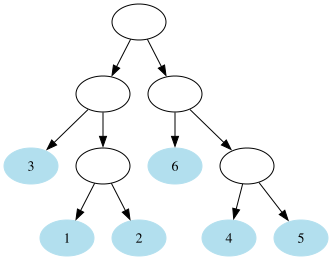

[0, 1, 4, 2, 3]

In [21]:
naive_inner_postorder_of_ordinal(canonical_ordinal([(1,2), (3,4), (1,2), (2,3), (1,2)]))

In [22]:
o = canonical_ordinal(random_ordinal(6))

{'left': {'left': {'left': {'left': 1, 'right': 3, 'val': 0}, 'right': 4, 'val': 1}, 'right': 5, 'val': 2}, 'right': {'left': 2, 'right': 6, 'val': 3}, 'val': 4}
{'left': {'left': {'left': 1, 'right': 3, 'val': 0}, 'right': 4, 'val': 1}, 'right': 5, 'val': 2}
{'left': {'left': 1, 'right': 3, 'val': 0}, 'right': 4, 'val': 1}
{'left': 1, 'right': 3, 'val': 0}
{'left': 2, 'right': 6, 'val': 3}


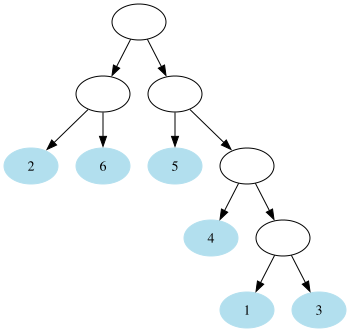

[0, 1, 2, 4, 3]

In [23]:
naive_inner_postorder_of_ordinal(o)

In [24]:
def compose_perms(a: list[int], b: list[int]) -> list[int]:
    return [b[a[i]] for i in range(len(a))]

def inverse_of_permutation(perm: list[int]) -> list[int]:
    inv = perm.copy()
    for i, pi in enumerate(perm):
        inv[pi] = i

    return inv

def spearman_rho_of_perm(a: list[int], b: list[int]) -> float:
    ab = compose_perms(a, b)
    ba = compose_perms(b, a)
    print(f'{a=}\n{b=}\n{ab=}\n{ba=}')
    b_inv = inverse_of_permutation(b)
    return sum(abs(i - b_inv[ai]) for i, ai in enumerate(a))

def inner_post_spearman_rho_of_ordinal(a: Ordinal, b: Ordinal) -> float:
    return spearman_rho_of_perm(naive_inner_postorder_of_ordinal(a), naive_inner_postorder_of_ordinal(b))

{'left': {'left': {'left': 1, 'right': 2, 'val': 0}, 'right': {'left': 3, 'right': 4, 'val': 1}, 'val': 2}, 'right': {'left': 5, 'right': 6, 'val': 3}, 'val': 4}
{'left': {'left': 1, 'right': 2, 'val': 0}, 'right': {'left': 3, 'right': 4, 'val': 1}, 'val': 2}
{'left': 1, 'right': 2, 'val': 0}
{'left': 3, 'right': 4, 'val': 1}
{'left': 5, 'right': 6, 'val': 3}


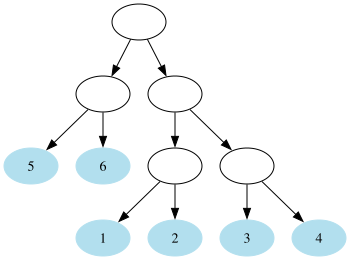

{'left': {'left': {'left': 1, 'right': 2, 'val': 0}, 'right': {'left': 3, 'right': 4, 'val': 1}, 'val': 2}, 'right': {'left': 5, 'right': 6, 'val': 3}, 'val': 4}
{'left': {'left': 1, 'right': 2, 'val': 0}, 'right': {'left': 3, 'right': 4, 'val': 1}, 'val': 2}
{'left': 1, 'right': 2, 'val': 0}
{'left': 3, 'right': 4, 'val': 1}
{'left': 5, 'right': 6, 'val': 3}


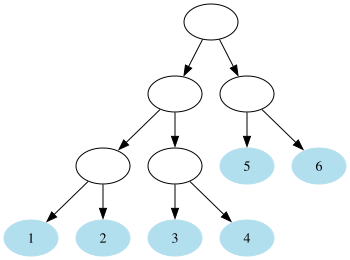

a=[0, 2, 1, 4, 3]
b=[0, 2, 1, 4, 3]
ab=[0, 1, 2, 3, 4]
ba=[0, 1, 2, 3, 4]


0

In [25]:
inner_post_spearman_rho_of_ordinal(
    canonical_ordinal([(1,2), (2,3), (3,4), (1,2), (1,2)]),
    canonical_ordinal([(1,2), (2,3), (1,2), (2,3), (1,2)])
)

{'left': {'left': {'left': {'left': {'left': 1, 'right': 2, 'val': 0}, 'right': 3, 'val': 1}, 'right': 4, 'val': 2}, 'right': 5, 'val': 3}, 'right': 6, 'val': 4}
{'left': {'left': {'left': {'left': 1, 'right': 2, 'val': 0}, 'right': 3, 'val': 1}, 'right': 4, 'val': 2}, 'right': 5, 'val': 3}
{'left': {'left': {'left': 1, 'right': 2, 'val': 0}, 'right': 3, 'val': 1}, 'right': 4, 'val': 2}
{'left': {'left': 1, 'right': 2, 'val': 0}, 'right': 3, 'val': 1}
{'left': 1, 'right': 2, 'val': 0}


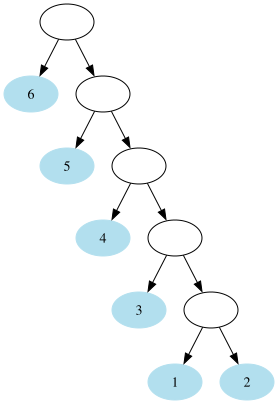

{'left': 1, 'right': {'left': 2, 'right': {'left': 3, 'right': {'left': 4, 'right': {'left': 5, 'right': 6, 'val': 0}, 'val': 1}, 'val': 2}, 'val': 3}, 'val': 4}
{'left': 2, 'right': {'left': 3, 'right': {'left': 4, 'right': {'left': 5, 'right': 6, 'val': 0}, 'val': 1}, 'val': 2}, 'val': 3}
{'left': 3, 'right': {'left': 4, 'right': {'left': 5, 'right': 6, 'val': 0}, 'val': 1}, 'val': 2}
{'left': 4, 'right': {'left': 5, 'right': 6, 'val': 0}, 'val': 1}
{'left': 5, 'right': 6, 'val': 0}


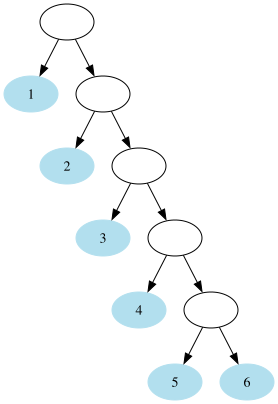

a=[0, 1, 2, 3, 4]
b=[4, 3, 2, 1, 0]
ab=[4, 3, 2, 1, 0]
ba=[4, 3, 2, 1, 0]


12

In [26]:
inner_post_spearman_rho_of_ordinal(
    canonical_ordinal([(1,2)] * 5),
    canonical_ordinal([(6 - i - 1, 6 - i) for i in range(0, 5)])
)

In [27]:
def path_length_histogram_of_ordinal(enc: Ordinal) -> list[int]:
    path_lens = [0] * (len(enc))
    tree = naive_tree_of_ordinal(enc)

    def in_order_dfs(node: Tree, path_len: int): 
        nonlocal path_lens
        if isinstance(node, int) and path_len > 0:
            path_lens[path_len - 1] += 1

        if isinstance(node, dict):
            in_order_dfs(node['left'], path_len + 1)
            in_order_dfs(node['right'], path_len + 1)

    in_order_dfs(tree, 0)

    return path_lens

In [28]:
path_length_histogram_of_ordinal(canonical_ordinal([(1,2)] * 5))

[1, 1, 1, 1, 2]

In [29]:
path_length_histogram_of_ordinal(canonical_ordinal([(6 - i - 1, 6 - i) for i in range(0, 5)]))

[1, 1, 1, 1, 2]

In [127]:
def l2dist(a: list[int], b: list[int]) -> float:
    from math import sqrt
    return sqrt(sum( (ai - bi)**2 for ai, bi in zip(a, b) ))

def naive_l2_path_len_dist(a: Ordinal, b: Ordinal) -> float:
    ah = path_length_histogram_of_ordinal(a)
    bh = path_length_histogram_of_ordinal(b)

    return l2dist(ah, bh)

In [116]:
import matplotlib.pyplot as plt
import matplotlib

# https://matplotlib.org/stable/gallery/images_contours_and_fields/image_annotated_heatmap.html
def heatmap(data, row_labels, col_labels, ax=None,
            cbar_kw=None, cbarlabel="", **kwargs):
    """
    Create a heatmap from a numpy array and two lists of labels.

    Parameters
    ----------
    data
        A 2D numpy array of shape (M, N).
    row_labels
        A list or array of length M with the labels for the rows.
    col_labels
        A list or array of length N with the labels for the columns.
    ax
        A `matplotlib.axes.Axes` instance to which the heatmap is plotted.  If
        not provided, use current Axes or create a new one.  Optional.
    cbar_kw
        A dictionary with arguments to `matplotlib.Figure.colorbar`.  Optional.
    cbarlabel
        The label for the colorbar.  Optional.
    **kwargs
        All other arguments are forwarded to `imshow`.
    """

    if ax is None:
        ax = plt.gca()

    if cbar_kw is None:
        cbar_kw = {}

    # Plot the heatmap
    im = ax.imshow(data, **kwargs)

    # Create colorbar
    cbar = ax.figure.colorbar(im, ax=ax, **cbar_kw)
    cbar.ax.set_ylabel(cbarlabel, rotation=-90, va="bottom")

    # Show all ticks and label them with the respective list entries.
    ax.set_xticks(range(data.shape[1]), labels=col_labels,
                  rotation=-30, ha="right", rotation_mode="anchor")
    ax.set_yticks(range(data.shape[0]), labels=row_labels)

    # Let the horizontal axes labeling appear on top.
    ax.tick_params(top=True, bottom=False,
                   labeltop=True, labelbottom=False)

    # Turn spines off and create white grid.
    ax.spines[:].set_visible(False)

    ax.set_xticks(np.arange(data.shape[1]+1)-.5, minor=True)
    ax.set_yticks(np.arange(data.shape[0]+1)-.5, minor=True)
    ax.grid(which="minor", color="w", linestyle='-', linewidth=0)
    ax.tick_params(which="minor", bottom=False, left=False)

    return im, cbar

# https://matplotlib.org/stable/gallery/images_contours_and_fields/image_annotated_heatmap.html
def annotate_heatmap(im, data=None, valfmt="{x:.2f}",
                     textcolors=("black", "white"),
                     threshold=None, **textkw):
    """
    A function to annotate a heatmap.

    Parameters
    ----------
    im
        The AxesImage to be labeled.
    data
        Data used to annotate.  If None, the image's data is used.  Optional.
    valfmt
        The format of the annotations inside the heatmap.  This should either
        use the string format method, e.g. "$ {x:.2f}", or be a
        `matplotlib.ticker.Formatter`.  Optional.
    textcolors
        A pair of colors.  The first is used for values below a threshold,
        the second for those above.  Optional.
    threshold
        Value in data units according to which the colors from textcolors are
        applied.  If None (the default) uses the middle of the colormap as
        separation.  Optional.
    **kwargs
        All other arguments are forwarded to each call to `text` used to create
        the text labels.
    """

    if not isinstance(data, (list, np.ndarray)):
        data: NDArray = im.get_array()

    # Normalize the threshold to the images color range.
    if threshold is not None:
        threshold = im.norm(threshold)
    else:
        threshold = im.norm(np.max(data))/2.

    # Set default alignment to center, but allow it to be
    # overwritten by textkw.
    kw = dict(horizontalalignment="center",
              verticalalignment="center")
    kw.update(textkw)

    # Get the formatter in case a string is supplied
    if isinstance(valfmt, str):
        valfmt = matplotlib.ticker.StrMethodFormatter(valfmt)

    # Loop over the data and create a `Text` for each "pixel".
    # Change the text's color depending on the data.
    texts = []
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            kw.update(color=textcolors[int(im.norm(data[i, j]) < threshold)])
            text = im.axes.text(j, i, valfmt(data[i, j], None), **kw)
            texts.append(text)

    return texts


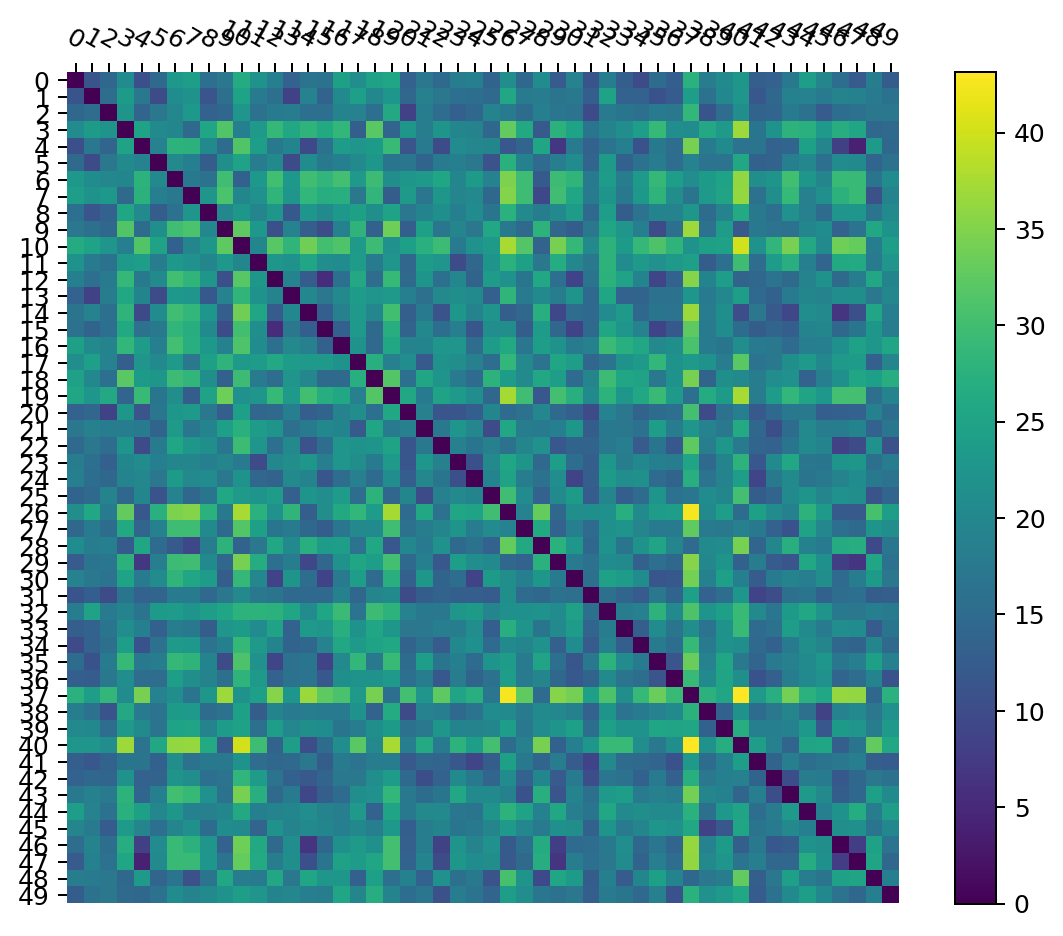

In [129]:
import altair as alt
import numpy as np

"""
Wygląda na pseudomiarę?
"""

N = 100
P = 50
population : list[Ordinal] = list(map(canonical_ordinal, [
        random_ordinal(N)
        for _ in range(P)
    ]))
histograms = list(map(path_length_histogram_of_ordinal, population))
M = np.zeros((P, P))
for i in range(len(population)):
    for j in range(len(population)):
        M[i, j] = l2dist(histograms[i], histograms[j])

plt.figure(figsize=(8, 6), dpi=180)
im, cbar = heatmap(M, list(range(P)), list(range(P)))
im        

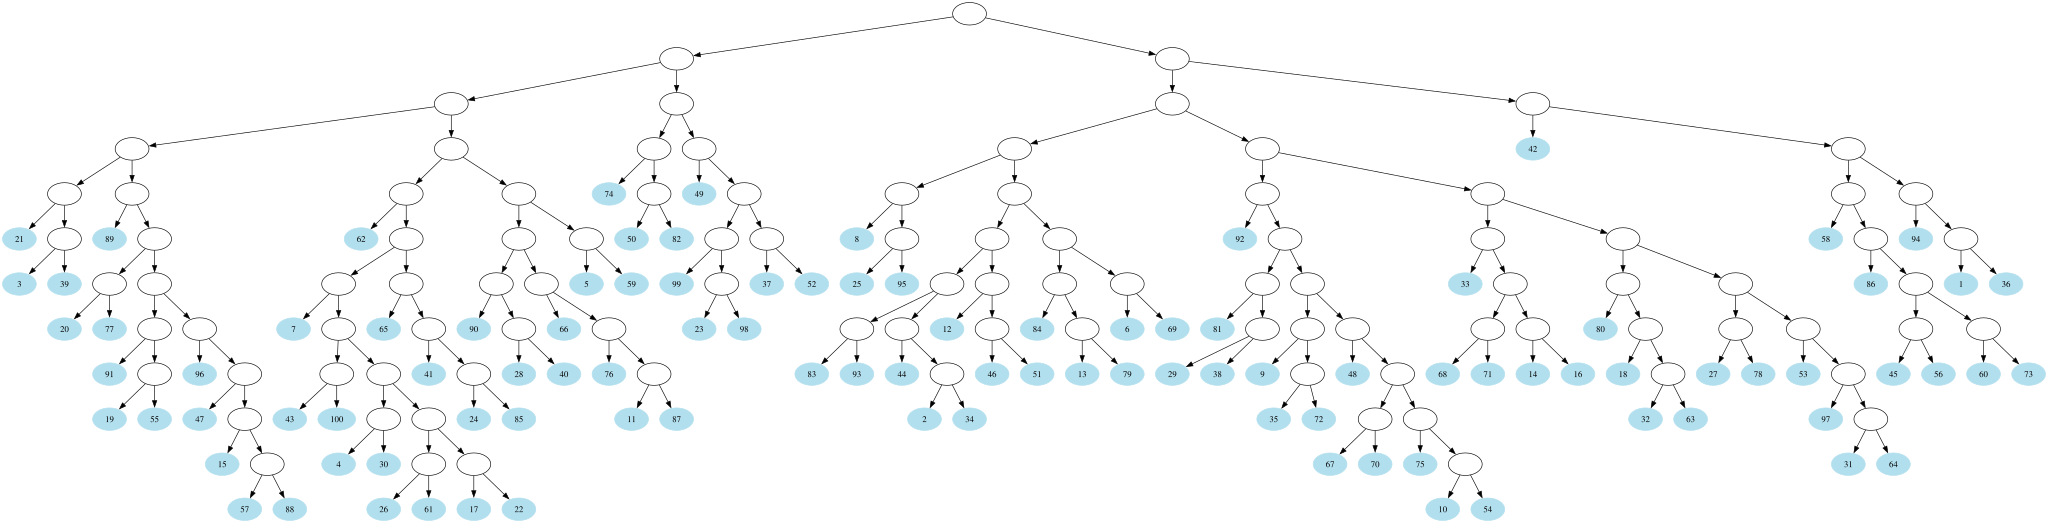

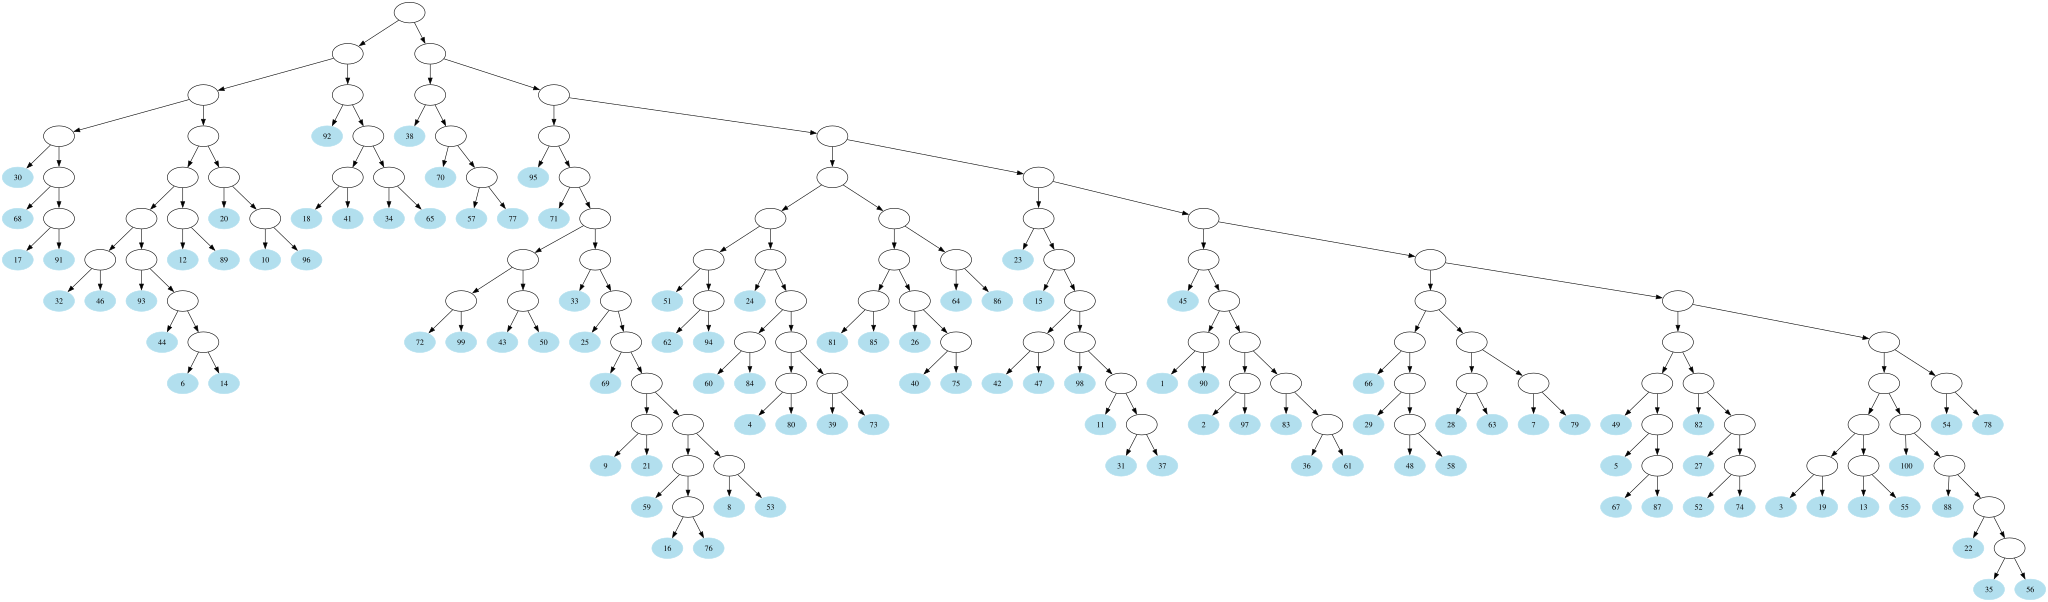

In [135]:
gis = [47, 48]
for gi in gis:
    display(naive_digraph_of_ordinal(population[gi])[0])

In [105]:
def newick_of_ordinal(enc: Ordinal) -> str:
    t = naive_tree_of_ordinal(enc)

    def aux(node: Tree) -> str:
        if isinstance(node, dict):
            return f"({aux(node['left'])},{aux(node['right'])})"
        else:
            return f"{node}"

    return f'{aux(t)};'

In [137]:
print(newick_of_ordinal(population[47]))
print("\n", newick_of_ordinal(population[48]))


((((((1,36),94),((((45,56),(60,73)),86),58)),42),(((((((2,34),44),(83,93)),(12,(46,51))),((6,69),((13,79),84))),(8,(25,95))),(((((9,(35,72)),((((10,54),75),(67,70)),48)),((29,38),81)),92),((((14,16),(68,71)),33),(((18,(32,63)),80),((27,78),(((31,64),97),53))))))),(((((3,39),21),((((((15,(57,88)),47),96),((19,55),91)),(20,77)),89)),(((((((4,30),((17,22),(26,61))),(43,100)),7),(((24,85),41),65)),62),((5,59),((((11,87),76),66),((28,40),90))))),(((((23,98),99),(37,52)),49),((50,82),74))));

 (((((((((1,90),((2,97),((36,61),83))),45),((((((3,19),(13,55)),(((22,(35,56)),88),100)),(54,78)),(((5,(67,87)),49),((27,(52,74)),82))),(((7,79),(28,63)),((29,(48,58)),66)))),(((((11,(31,37)),98),(42,47)),15),23)),((((((4,80),(39,73)),(60,84)),24),(51,(62,94))),(((26,(40,75)),(81,85)),(64,86)))),(((((((((8,53),((16,76),59)),(9,21)),69),25),33),((43,50),(72,99))),71),95)),(38,((57,77),70))),((((((((6,14),44),93),(32,46)),(12,89)),((10,96),20)),(((17,91),68),30)),(((18,41),(34,65)),92)));


In [134]:
Measure = Callable[[Ordinal, Ordinal], float]
def is_pseudo_measure(d: Measure, steps: int, size: int):
    def has_triangle_eq(x: Ordinal, y: Ordinal, z: Ordinal) -> bool:
        return d(x, y) <= d(x, z) + d(z, y)

    def is_symm(x: Ordinal, y: Ordinal) -> bool:
        return d(x, y) == d(y, x)
    
    for _ in range(steps):
        x, y, z = map(canonical_ordinal, [random_ordinal(size) for _ in range(3)])

        if not is_symm(x, y):
            print(f"NOT SYMMETRIC {x=}, {y=}")
        if not has_triangle_eq(x, y, z):
            print(f"NOT TRIENGLE {x=}, {y=}, {z=}")


is_pseudo_measure(naive_l2_path_len_dist, 1000, 1000)